[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/01_postfit_sqlite_pipeline.ipynb)


In [1]:
# Colab / local repository setup
# Run this cell first when opening the notebook in Google Colab. It clones the
# repository, installs the pinned requirements, and makes data/ plus src/ imports
# available from the same execution context used by the local notebooks.
from pathlib import Path
import os
import subprocess
import sys


def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


def _run(command, cwd=None):
    print("$", " ".join(command))
    subprocess.run(command, cwd=cwd, check=True)


REPO_URL = os.environ.get("ASTROMODEL_REPO_URL", "https://github.com/doxav/astromodel_proving.git")
REPO_BRANCH = os.environ.get("ASTROMODEL_REPO_BRANCH", "main")
PROJECT_DIRNAME = os.environ.get("ASTROMODEL_PROJECT_DIRNAME", "astromodel_proving")

if _running_in_colab():
    project_root = Path("/content") / PROJECT_DIRNAME
    if not project_root.exists():
        clone_cmd = [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            REPO_BRANCH,
            REPO_URL,
            str(project_root),
        ]
        try:
            _run(clone_cmd)
        except subprocess.CalledProcessError:
            # Some forks/default branches may not be named like REPO_BRANCH.
            # Retry without an explicit branch before surfacing the clone error.
            _run(["git", "clone", "--depth", "1", REPO_URL, str(project_root)])
    os.chdir(project_root)
    requirements = project_root / "requirements.txt"
    if requirements.exists():
        _run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements)])
else:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    project_root = next(
        (
            candidate
            for candidate in candidates
            if (candidate / "src").is_dir() and (candidate / "data").is_dir()
        ),
        current,
    )
    os.chdir(project_root)

os.environ["ASTROMODEL_PROJECT_ROOT"] = str(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"ASTROMODEL_PROJECT_ROOT={project_root}")
print(f"Working directory={Path.cwd()}")
print(f"data exists={(project_root / 'data').exists()}, src exists={(project_root / 'src').exists()}")


ASTROMODEL_PROJECT_ROOT=/home/xav/code/astromodel_proving
Working directory=/home/xav/code/astromodel_proving
data exists=True, src exists=True


# Step 01 — SQLite post-fit pipeline and hidden-mechanism summaries

This notebook reruns the **legacy single-current post-fit summaries** used for reviewer-response context.

## Reuse from `astro_atf_analysis_improved_sectioned.ipynb`

None of the ATF parsing, preprocessing, or sweep-feature extraction logic is reused here.  
This step interprets the **historical Optuna DB summaries**, not the new ATF dataset.

## Interpretation boundary

Because historical control provenance remains unresolved in step 00, the outputs below should be treated as:
- structural-confounding diagnostics,
- effective-parameter summaries,
- and provisional mechanism narratives,

not as final reviewer-facing mechanism proof.

In [2]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.postfit_sqlite import d_pk_invariance_check, run_step01_postfit_sqlite

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT

PosixPath('/home/xav/code/astromodel_proving')

In [3]:
results = run_step01_postfit_sqlite(PROJECT_ROOT, legacy_top_n=300)
top_trials_df = results["top_trials_all_dbs"]
legacy_library = results["legacy_configuration_library"]
legacy_status = results["legacy_configuration_status_by_db"]
legacy_factors = results["legacy_condition_parameter_ratios"]
effective_df = results["effective_parameter_summary"]
representative_df = results["representative_mechanism_summary"]

print("written outputs:", sorted((PROJECT_ROOT / "outputs" / "postfit_sqlite").glob("*.csv")))
print(
    "top-trial rows:", len(top_trials_df),
    "legacy library rows:", len(legacy_library),
    "effective rows:", len(effective_df),
    "representative rows:", len(representative_df),
)


written outputs: [PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/effective_parameter_summary.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/legacy_condition_parameter_ratios.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/legacy_configuration_library.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/legacy_configuration_status_by_db.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/representative_mechanism_summary.csv'), PosixPath('/home/xav/code/astromodel_proving/outputs/postfit_sqlite/top_trials_all_dbs.csv')]
top-trial rows: 90 legacy library rows: 5400 effective rows: 18 representative rows: 3


## `d × pk` confounding check

In [4]:
base_params = {
    "gki": 50.0,
    "pk": 2e-4,
    "d": 3.0,
    "gt": 8.0,
    "gs": 10.0,
    "zth": 0.2,
    "zs": 0.05,
    "K_bath_value_middle": 8.2,
    "eps": 0.01,
    "eps_middle": 0.5,
    "wo": 1500.0,
    "ca": 400.0,
    "gl_a": 0.01,
    "Va_l": -70.0,
    "Va_s": -90.0,
    "switching_function": "sigmoid",
}
check = d_pk_invariance_check(base_params)
display(
    pd.DataFrame(
        [
            {
                "P_gap_eff_a": check.P_gap_eff_a,
                "P_gap_eff_b": check.P_gap_eff_b,
                "I_kgap_a": check.I_kgap_a,
                "I_kgap_b": check.I_kgap_b,
                "max_abs_rhs_delta": float(abs(check.dzdt_a - check.dzdt_b).max()),
            }
        ]
    )
)

,P_gap_eff_a,P_gap_eff_b,I_kgap_a,I_kgap_b,max_abs_rhs_delta
0,0.0006,0.0006,1866.960713,1866.960713,0.0


## Effective parameter summary (all 18 DBs)

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,1,0,3450.286230,3.820129e-04,0.000077,0.000047,2.776433
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,1,0,5848.293742,5.145793e-04,0.000033,0.000319,2.274250
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,3.060630e-04,0.000057,0.000329,2.888380
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,1,0,13492.704819,2.694143e-04,0.000048,0.000112,1.585457
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,4312,4311,23509.572968,2.099761e-04,0.000058,0.000255,3.071149
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,1,0,28903.238239,3.980285e-04,0.000030,0.000016,1.585018
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,2068,2067,21.502226,4.282360e-06,0.000052,0.000091,1.308028
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,7.688695e-06,0.000008,0.000069,1.527016
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,1944,1943,38.365141,4.567634e-08,0.000026,0.000080,1.465699
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,1930,1929,102.645495,6.177250e-08,0.000008,0.000131,1.014964


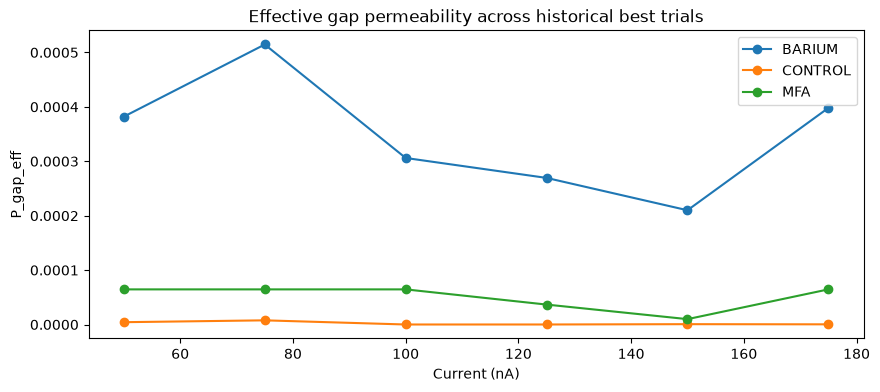

In [5]:
display(effective_df)

fig, ax = plt.subplots(figsize=(10, 4))
for condition, group in effective_df.groupby("condition"):
    ax.plot(group["current_na"], group["P_gap_eff"], marker="o", label=condition)
ax.set_xlabel("Current (nA)")
ax.set_ylabel("P_gap_eff")
ax.set_title("Effective gap permeability across historical best trials")
ax.legend()
plt.show()

## Legacy top-300 configuration library

This first-pass library is explicitly `top_n_by_objective`, not threshold-accepted fits. The rows are source-scoped as legacy single-current Optuna configurations and are used downstream for legacy mechanism/function mapping.


In [6]:
display(legacy_status)
display(legacy_library.head(20))
assert legacy_library["legacy_acceptance_rule"].eq("not_thresholded_top_n_first_pass").all()
assert "accepted" not in legacy_library.columns


,db_name,condition,legacy_protocol_condition,current_na,n_configurations,legacy_top_n_requested,legacy_top_n_available,best_objective,worst_included_objective,provenance_status,legacy_configuration_status,legacy_acceptance_rule
0,CONTROL_50nA.db,CONTROL,CONTROL,50,300,300,300,21.502226,8.604713e+01,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
1,CONTROL_75nA.db,CONTROL,CONTROL,75,300,300,300,30.054498,9.568785e+01,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
2,CONTROL_100nA.db,CONTROL,CONTROL,100,300,300,300,38.365141,8.460563e+01,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
3,CONTROL_125nA.db,CONTROL,CONTROL,125,300,300,300,102.645495,2.455498e+02,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
4,CONTROL_150nA.db,CONTROL,CONTROL,150,300,300,300,107.265066,2.468992e+02,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
5,CONTROL_175nA.db,CONTROL,CONTROL,175,300,300,300,122.596790,1.461046e+03,unresolved,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
6,MFA_50nA.db,MFA,MFA,50,300,300,300,98069.098196,2.663102e+05,verified,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
7,MFA_75nA.db,MFA,MFA,75,300,300,300,105235.350690,6.355328e+05,verified,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
8,MFA_100nA.db,MFA,MFA,100,300,300,300,135164.788205,1.476384e+06,verified,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass
9,MFA_125nA.db,MFA,MFA,125,300,300,300,128775.804486,1.933386e+06,verified,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass


,source_scope,legacy_configuration_status,legacy_acceptance_rule,legacy_selection_rule,legacy_top_n_requested,legacy_top_n_available,rank_in_db,db_name,study_name,condition,legacy_protocol_condition,current_na,trial_id,trial_number,objective,K_bath_value_middle,Va_l,Va_s,ca,d,eps,eps_middle,gki,gl_a,gs,gt,pk,switching_function,wo,zs,zth,wo_middle,w_a,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo,w_o_middle,provenance_status,chosen_provenance_status,trace_dataset_kind,chosen_trace_source
0,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,1,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2068,2067,21.502226,7.948467,-66.114614,-91.459849,558.802369,0.078422,0.001656,1.0,153.293517,1.463739,10.972646,6.252492,5.460637e-05,sigmoid,1529.018861,9.993185,26.454507,1.0,2000.0,4.282360e-06,0.000052,0.000091,1.308028,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
1,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,2,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2183,2182,24.608913,7.925688,-73.201086,-90.330184,618.904499,0.021625,0.001603,1.0,153.084451,1.292780,10.894226,8.285803,1.086349e-04,sigmoid,1484.807279,9.634384,25.401323,1.0,2000.0,2.349273e-06,0.000069,0.000090,1.346976,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
2,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,3,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2263,2262,24.963259,7.924951,-75.747620,-90.308617,568.936586,0.016391,0.001508,1.0,144.870558,1.941258,11.433385,7.718580,7.845322e-05,sigmoid,1524.698795,9.685946,28.831453,1.0,2000.0,1.285898e-06,0.000064,0.000095,1.311734,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
3,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,4,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2251,2250,25.767272,7.916343,-74.905454,-90.829471,549.125750,0.029608,0.001701,1.0,147.819710,1.614105,10.709593,7.313028,9.920903e-05,sigmoid,1519.682163,9.574526,28.854411,1.0,2000.0,2.937395e-06,0.000061,0.000089,1.316065,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
4,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,5,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2414,2413,26.217796,8.104162,-79.116155,-92.867681,518.505318,0.001916,0.001671,1.0,171.043344,3.409834,10.523563,6.259206,6.724883e-07,sigmoid,1207.330005,9.160629,38.741499,1.0,2000.0,1.288556e-09,0.000052,0.000087,1.656548,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
5,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2483,2482,26.249233,8.097169,-78.280155,-91.983723,530.218810,0.022359,0.001708,1.0,181.630696,3.630863,2.163601,5.826276,2.693212e-06,sigmoid,1286.949386,8.680510,42.595369,1.0,2000.0,6.021719e-08,0.000048,0.000018,1.554063,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
6,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,7,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,CONTROL,50,2159,2158,27.249974,7.832812,-71.770071,-90.006101,568.792031,0.027760,0.001547,1.0,152.509142,1.365639,11.038637,7.529360,1.002084e-04,sigmoid,1533.019393,9.801733,27.496828,1.0,2000.0,2.781797e-06,0.000062,0.000092,1.304615,NaN,unresolved,unresolved,legacy_optuna_trace_csv,CONTROL_TRACES.csv
7,legacy_single_current_optuna,legacy_top300_optuna_trial,not_thresholded_top_n_first_pass,top_n_by_objective,300,300,8,CONTROL_50nA.db

## Legacy perturbation factor candidates

These factors combine legacy condition-ratio candidates with the Filtered baseline fold grid. They are first-pass model perturbation factors, not Naris-derived biological magnitudes.


In [7]:
display(legacy_factors.head(40))
assert {"filter_baseline_fold_grid", "legacy_top_trial_ratio"}.issubset(set(legacy_factors["factor_source"]))


,condition_pair,perturbation_context,current_na,parameter,factor,factor_source,factor_status
0,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,0.50,filter_baseline_fold_grid,first_pass_grid_factor
1,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,0.75,filter_baseline_fold_grid,first_pass_grid_factor
2,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,1.00,filter_baseline_fold_grid,first_pass_grid_factor
3,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,1.25,filter_baseline_fold_grid,first_pass_grid_factor
4,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,1.50,filter_baseline_fold_grid,first_pass_grid_factor
5,fold_grid,MFA_BA_from_MFA_legacy,-1,P_gap_eff,2.00,filter_baseline_fold_grid,first_pass_grid_factor
6,fold_grid,MFA_BA_from_MFA_legacy,-1,gamma_s_eff,0.50,filter_baseline_fold_grid,first_pass_grid_factor
7,fold_grid,MFA_BA_from_MFA_legacy,-1,gamma_s_eff,0.75,filter_baseline_fold_grid,first_pass_grid_factor
8,fold_grid,MFA_BA_from_MFA_legacy,-1,gamma_s_eff,1.00,filter_baseline_fold_grid,first_pass_grid_factor
9,fold_grid,MFA_BA_from_MFA_legacy,-1,gamma_s_eff,1.25,filter_baseline_fold_grid,first_pass_grid_factor


## Representative mechanism summary

,db_name,study_name,condition,current_na,trial_id,trial_number,objective,P_gap_eff,gamma_t_eff,gamma_s_eff,volume_ratio_wa_wo,I_Kir_integral,I_kgap_integral,I_leak_integral,I_k_a_integral,I_Kir_peak_abs,I_kgap_peak_abs,gap_to_kir_integral_ratio,gap_kir_classification,gap_fraction,kir_fraction,leak_fraction,K_o_baseline,K_o_peak,K_o_final,K_o_delta_peak,K_o_recovery_error,dominant_mechanism,proxy_proxy,proxy_target,proxy_pearson_r,proxy_spearman_r,proxy_rmse_after_scaling,proxy_lag_s_at_max_corr,proxy_validity_class
0,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,1,0,7963.653221,0.000306,0.000057,0.000329,2.888380,758.948755,12841.307868,12083.699598,0.0,180.187113,860.144325,16.919862,gap_dominant,0.499974,0.029550,0.470477,4.798852,7.596770,5.112036,2.797918,0.313184,Mixed,DK_a_t,K_o,0.999925,1.000000,0.007149,0.0,strong
1,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,2426,2425,30.054498,0.000008,0.000008,0.000069,1.527016,1540.504132,1888.367069,354.913439,0.0,89.057591,100.638353,1.225811,mixed,0.499068,0.407133,0.093799,5.017496,8.395908,5.123680,3.378412,0.106184,Mixed,DK_a_t,K_o,0.454297,1.000000,0.311064,0.0,weak
2,MFA_100nA.db,MFA_100nA_centered_COMBINED_20000t_2024-10-13_...,MFA,100,1,0,135164.788205,0.000065,0.000018,0.001280,0.190203,12307.104983,14975.484599,2672.666492,0.0,628.860054,760.533827,1.216816,mixed,0.499928,0.410850,0.089222,4.561722,7.971894,4.570440,3.410172,0.008718,Mixed,DK_a_t,K_o,-0.223945,0.357925,0.536267,0.0,failed


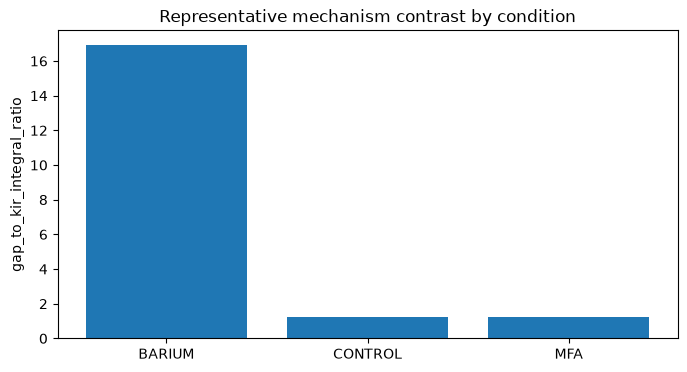

In [8]:
display(representative_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(representative_df["condition"], representative_df["gap_to_kir_integral_ratio"])
ax.set_ylabel("gap_to_kir_integral_ratio")
ax.set_title("Representative mechanism contrast by condition")
plt.show()

## Consequence for the reviewer response

Step 01 still supports the mechanistic framing that **effective combinations** matter more than raw `d` or `pk` alone.  
However, because it is built on legacy single-current fits — and because historical control provenance is still unresolved — the strongest reviewer-facing evidence among steps 00-02 remains the ATF-based step 02 thresholds and region summaries.

## Post-execution scientific status

Executed status for reviewer response: Step 01 remains legacy single-current context, but now also writes the first-pass top-300 legacy Optuna configuration library, DB-level source status, and perturbation factor candidates used by the legacy mechanism/function and perturbation layers. These top-N rows are not threshold-accepted fits; thresholded good-enough selection remains a later optional layer. The output supports R1/R4 by making effective-coordinate interpretation explicit and supports Step 05/06 by providing source-scoped legacy configurations and Filtered-baseline fold factors.
